In [ ]:
!pip install kaggle tensorflow matplotlib pandas

In [ ]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"meenakshimnair","key":"47573055b019df6dc5cc752c8d28a366"}'}

In [ ]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [ ]:
!kaggle datasets download -d jessicali9530/celeba-dataset

Dataset URL: https://www.kaggle.com/datasets/jessicali9530/celeba-dataset
License(s): other
100% 1.33G/1.33G [00:35<00:00, 40.5MB/s]



In [ ]:
import zipfile

with zipfile.ZipFile("celeba-dataset.zip",'r') as zip_ref:
    zip_ref.extractall("celeba")

In [ ]:
import os
import numpy as np
import pandas as pd
import random
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow.keras import layers, Model
from tensorflow.keras.preprocessing import image
from tensorflow.keras.utils import img_to_array

In [ ]:
data_dir = "celeba/img_align_celeba/img_align_celeba"
attr_file = "celeba/list_attr_celeba.csv"

In [ ]:
attr = pd.read_csv(attr_file)

attr = attr[(attr['Black_Hair']==1) | (attr['Blond_Hair']==1)]

attr = attr.sample(10000, random_state=42)

attr = attr.reset_index(drop=True)

print(attr.head())

     image_id  5_o_Clock_Shadow  Arched_Eyebrows  Attractive  Bags_Under_Eyes  \
0  125435.jpg                -1               -1           1                1   
1  068444.jpg                -1                1           1               -1   
2  052161.jpg                -1                1           1               -1   
3  004425.jpg                -1               -1          -1               -1   
4  004601.jpg                -1                1           1               -1   

   Bald  Bangs  Big_Lips  Big_Nose  Black_Hair  ...  Sideburns  Smiling  \
0    -1      1        -1         1          -1  ...         -1        1   
1    -1     -1        -1        -1           1  ...         -1       -1   
2    -1      1         1        -1          -1  ...         -1        1   
3    -1     -1        -1        -1           1  ...         -1        1   
4    -1     -1        -1        -1           1  ...         -1        1   

   Straight_Hair  Wavy_Hair  Wearing_Earrings  Wearing_Hat  We

In [ ]:
X=[]
y=[]

for idx,row in attr.iterrows():

    img_path = os.path.join(data_dir,row['image_id'])

    img=image.load_img(img_path,target_size=(64,64))

    img_array=img_to_array(img)/255.0

    X.append(img_array)

    y.append(1 if row['Blond_Hair']==1 else 0)

X=np.array(X)
y=np.array(y)

print(X.shape)

(10000, 64, 64, 3)


In [ ]:
  latent_dim = 64

  encoder_inputs = layers.Input(shape=(64,64,3))

  x = layers.Conv2D(32,3,strides=2,padding="same",activation="relu")(encoder_inputs)
  x = layers.Conv2D(64,3,strides=2,padding="same",activation="relu")(x)

  x = layers.Flatten()(x)
  x = layers.Dense(128,activation="relu")(x)

  z_mean = layers.Dense(latent_dim,name="z_mean")(x)
  z_log_var = layers.Dense(latent_dim,name="z_log_var")(x)

  class Sampling(layers.Layer):
      def call(self, inputs):
          z_mean,z_log_var = inputs
          epsilon = tf.random.normal(shape=(tf.shape(z_mean)[0],latent_dim))
          return z_mean + tf.exp(0.5*z_log_var) * epsilon

  z = Sampling()([z_mean,z_log_var])

  encoder = Model(encoder_inputs,[z_mean,z_log_var,z],name="encoder")
  encoder.summary()

Model: "encoder"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 64, 64, 3) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 32, 32,    │        896 │ input_layer_1[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 16, 16,    │     18,496 │ conv2d[0][0]      │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten (Flatten)   │ (None, 16384)     │          0 │ conv2d_1[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 128)       │  2,097,280 │ flatten[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ z_mean (Dense)      │ (None, 64)        │      8,256 │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ z_log_var (Dense)   │ (None, 64)        │      8,256 │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sampling (Sampling) │ (None, 64)        │          0 │ z_mean[0][0],     │
│                     │                   │            │ z_log_var[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 2,133,184 (8.14 MB)

 Trainable params: 2,133,184 (8.14 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
latent_inputs = layers.Input(shape=(latent_dim,))

x = layers.Dense(8*8*256, activation='relu')(latent_inputs)
x = layers.Reshape((8,8,256))(x)

x = layers.Conv2DTranspose(256,3,strides=2,padding='same',activation='relu')(x)
x = layers.Conv2DTranspose(128,3,strides=2,padding='same',activation='relu')(x)
x = layers.Conv2DTranspose(64,3,strides=2,padding='same',activation='relu')(x)

decoder_outputs = layers.Conv2DTranspose(3,3,padding='same',activation='sigmoid')(x)

decoder = Model(latent_inputs, decoder_outputs, name="decoder")

decoder.summary()

Model: "decoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16384)          │     1,064,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape_1 (Reshape)             │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_3              │ (None, 16, 16, 256)    │       590,080 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_4              │ (None, 32, 32, 128)    │       295,040 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_5              │ (None, 64, 64, 64)     │        73,792 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_6              │ (None, 64, 64, 3)      │         1,731 │
│ (Conv2DTranspose)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,025,603 (7.73 MB)

 Trainable params: 2,025,603 (7.73 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
class VAE(Model):

    def __init__(self, encoder, decoder, **kwargs):
        super().__init__(**kwargs)
        self.encoder = encoder
        self.decoder = decoder

    def train_step(self, data):

        if isinstance(data, tuple):
            data = data[0]

        with tf.GradientTape() as tape:

            z_mean, z_log_var, z = self.encoder(data)

            reconstruction = self.decoder(z)

            reconstruction_loss = tf.reduce_mean(
                tf.reduce_sum(
                    tf.keras.losses.binary_crossentropy(data, reconstruction),
                    axis=(1,2)
                )
            )

            kl_loss = -0.5 * tf.reduce_mean(
                tf.reduce_sum(
                    1 + z_log_var - tf.square(z_mean) - tf.exp(z_log_var),
                    axis=1
                )
            )

            total_loss = reconstruction_loss + kl_loss

        grads = tape.gradient(total_loss, self.trainable_weights)
        self.optimizer.apply_gradients(zip(grads, self.trainable_weights))

        return {
            "loss": total_loss,
            "reconstruction_loss": reconstruction_loss,
            "kl_loss": kl_loss,
        }

vae = VAE(encoder, decoder)
vae.compile(optimizer=tf.keras.optimizers.Adam())

In [ ]:
vae.fit(X, epochs=20, batch_size=64)

Epoch 1/20
157/157 ━━━━━━━━━━━━━━━━━━━━ 328s 2s/step - kl_loss: 17.7057 - loss: 2364.0281 - reconstruction_loss: 2346.3223
Epoch 2/20
157/157 ━━━━━━━━━━━━━━━━━━━━ 380s 2s/step - kl_loss: 18.5610 - loss: 2286.1875 - reconstruction_loss: 2267.6265
Epoch 3/20
157/157 ━━━━━━━━━━━━━━━━━━━━ 390s 2s/step - kl_loss: 19.5445 - loss: 2269.9243 - reconstruction_loss: 2250.3799
Epoch 4/20
157/157 ━━━━━━━━━━━━━━━━━━━━ 325s 2s/step - kl_loss: 18.9168 - loss: 2305.4272 - reconstruction_loss: 2286.5105
Epoch 5/20
157/157 ━━━━━━━━━━━━━━━━━━━━ 329s 2s/step - kl_loss: 19.3230 - loss: 2255.0991 - reconstruction_loss: 2235.7761
Epoch 6/20
157/157 ━━━━━━━━━━━━━━━━━━━━ 378s 2s/step - kl_loss: 17.7847 - loss: 2247.2031 - reconstruction_loss: 2229.4185
Epoch 7/20
157/157 ━━━━━━━━━━━━━━━━━━━━ 327s 2s/step - kl_loss: 17.9113 - loss: 2284.8831 - reconstruction_loss: 2266.9717
Epoch 8/20
157/157 ━━━━━━━━━━━━━━━━━━━━ 383s 2s/step - kl_loss: 18.2684 - loss: 2294.1655 - reconstruction_loss: 2275.8972
Epoch 9/20
157/1

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 141ms/step


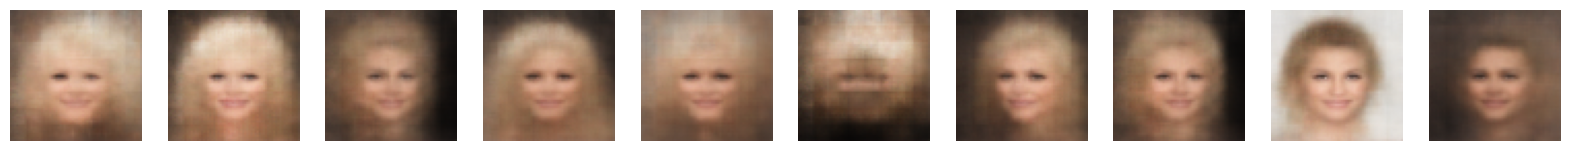

In [ ]:
import matplotlib.pyplot as plt

n = 10
z_sample = np.random.normal(size=(n, latent_dim))

generated_images = decoder.predict(z_sample)

plt.figure(figsize=(20,4))

for i in range(n):
    plt.subplot(1,n,i+1)
    plt.imshow(generated_images[i])
    plt.axis("off")

plt.show()